# Finding Stereoisomers of Molecules #

In [16]:
from rdkit import Chem

from stereomolgraph import StereoMolGraph
from stereomolgraph.experimental import generate_stereoisomers
from stereomolgraph.ipython import View2D

from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

View2D.show_atom_numbers = True
View2D.show_h = False
View2D.generate_bond_orders = True  # bond orders are not used internally

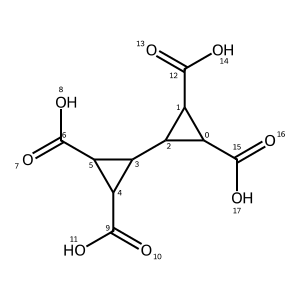

In [17]:
rdmol = Chem.AddHs(
    Chem.MolFromSmiles("[CH]1([CH](C1C2[CH]([CH]2C(=O)O)C(=O)O)C(=O)O)C(=O)O")
)
smg = StereoMolGraph.from_rdmol(rdmol, stereo_complete=False)
smg

### Construction from `rdkit.Mol`

When constructing from an `rdkit.Mol` with `stereo_complete=False`, any atom without explicitly defined stereochemistry is treated as **undefined**.

Using `generate_stereoisomers` will enumerate all **distinct stereoisomers** without producing duplicates.

In [18]:
isomers = list(generate_stereoisomers(smg, enantiomers=False))
# enantiomes are removed
len(isomers)

10

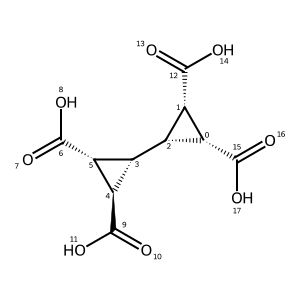

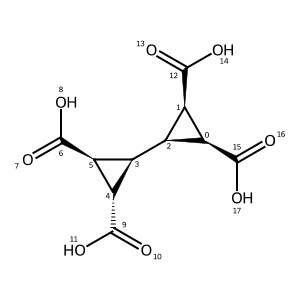

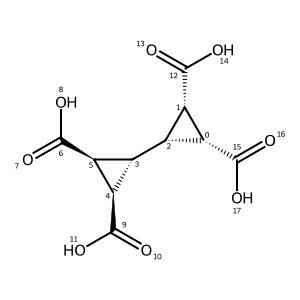

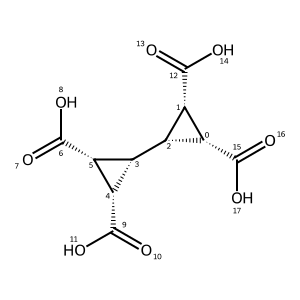

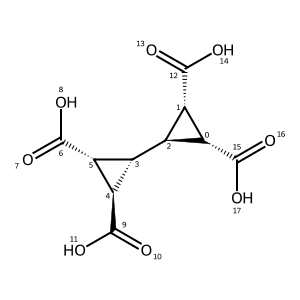

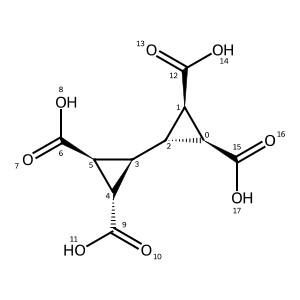

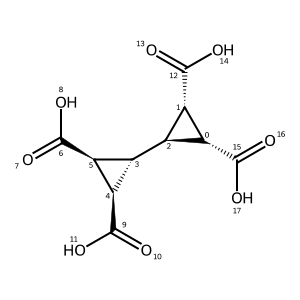

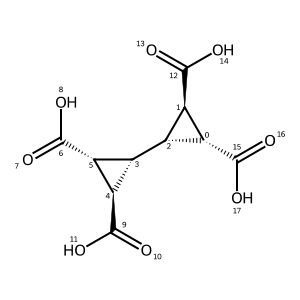

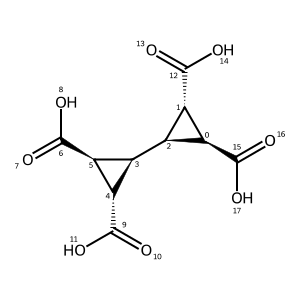

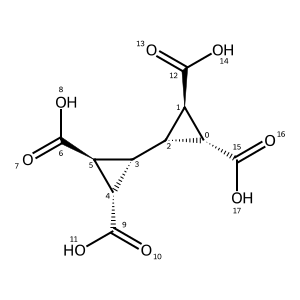

In [19]:
for isomer in isomers:
    isomer

In [20]:
all_isomers_stereo = []

for i in isomers:
    rdmol = i.to_rdmol(generate_bond_orders=True)

    stereocenters = Chem.FindMolChiralCenters(
        rdmol, includeUnassigned=False, force=True
    )

    isomer_stereo = []
    for atom_idx, stereo in stereocenters:
        atom = rdmol.GetAtomWithIdx(atom_idx)
        atom_idx = atom.GetIdx()
        isomer_stereo.append((atom_idx, stereo))

    isomer_stereo.sort()
    all_isomers_stereo.append(isomer_stereo)

all_isomers_stereo.sort()
all_isomers_stereo

[[(0, 'R'), (1, 'R'), (4, 'R'), (5, 'R')],
 [(0, 'R'), (1, 'R'), (4, 'S'), (5, 'S')],
 [(0, 'R'), (1, 'S'), (2, 'R'), (3, 'R'), (4, 'S'), (5, 'R')],
 [(0, 'R'), (1, 'S'), (2, 'R'), (3, 'S'), (4, 'R'), (5, 'S')],
 [(0, 'R'), (1, 'S'), (2, 'R'), (4, 'R'), (5, 'R')],
 [(0, 'R'), (1, 'S'), (2, 'S'), (3, 'S'), (4, 'R'), (5, 'S')],
 [(0, 'R'), (1, 'S'), (2, 'S'), (4, 'R'), (5, 'R')],
 [(0, 'S'), (1, 'R'), (2, 'R'), (4, 'S'), (5, 'S')],
 [(0, 'S'), (1, 'R'), (2, 'S'), (4, 'S'), (5, 'S')],
 [(0, 'S'), (1, 'S'), (4, 'S'), (5, 'S')]]